In [29]:
# !pip install dotenv
!pip install langchain_groq


In [30]:
!pip install python-dotenv

In [47]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    groq_api_key="GROQ_API_KEY",
    temperature=0
)



In [48]:
response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": "Explain customer churn in one sentence."
        }
    ]
)

print(response.choices[0].message.content)

Customer churn is the measure of how quickly and why customers stop doing business with a company, reflecting the loss of revenue and the need to improve retention.


In [49]:
import pandas as pd
file_path="/home/susan/Shyam/Autonomous-AI-Data-Aanalyst/data/Telco_customer_churn.xlsx"
df=pd.read_excel(file_path)
print(df)


      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender  ..

In [50]:
# to convert our existing python analysis into a tool that the LLM can call

from langchain_core.tools import tool

#@tool that tells langchain 
# -> this python function is available as a tool for the LLM
@tool
def dataset_overview():
    """
    Return basis information about the dataset.
    """

    return {
        "rows":len(df),
        "columns":len(df.columns),
        "column_names":df.columns.tolist()
    }

In [51]:
#create our statistics tool

@tool
def column_statistics(column_name:str):
    """
    calculate statistics for a dataset column.
    """

    if column_name not in df.columns:
        return f"Column '{column_name}' does not exists."

    column=df[column_name]

    if pd.api.types.is_numeric_dtype(column):
        return {
            "column":column_name,
            "type":"numerical",
            "count":int(column.count()),
            "mean":float(column.count()),
            "median":float(column.count()),
            "minimum":float(column.count()),
            "maximum":float(column.count()),
        }

    return {
        "column":column_name,
        "type": "categorical",
        "unique_values": int(column.nunique()),
        "value_counts":column.value_counts().head(10).to_dict()
    }

In [52]:
column_statistics.invoke({
    "column_name":"Monthly charges"
})

"Column 'Monthly charges' does not exists."

In [53]:
column_statistics.invoke({
    "column_name": "Contract"
})

{'column': 'Contract',
 'type': 'categorical',
 'unique_values': 3,
 'value_counts': {'Month-to-month': 3875, 'Two year': 1695, 'One year': 1473}}

In [54]:
column_statistics.invoke({
    "column_name": "Churn Label"
})

{'column': 'Churn Label',
 'type': 'categorical',
 'unique_values': 2,
 'value_counts': {'No': 5174, 'Yes': 1869}}

In [55]:
#create a churn analysis tool

@tool
def churn_analysis():
    """
    Analyze customer churn statistics.
    """

    churn_counts = df["Churn Label"].value_counts()

    churn_rate = (
        df["Churn Label"].eq("Yes").mean() * 100
    )

    return {
        "churned_customers": int(churn_counts.get("Yes", 0)),
        "non_churned_customers": int(churn_counts.get("No", 0)),
        "churn_rate_percentage": round(churn_rate, 2)
    }

In [56]:
churn_analysis.invoke({})

{'churned_customers': 1869,
 'non_churned_customers': 5174,
 'churn_rate_percentage': np.float64(26.54)}

In [57]:
import matplotlib.pyplot as plt
@tool
def visualize_column(column_name: str):
    """
    Create an appropriate visualization for a dataset column.
    """

    if column_name not in df.columns:
        return f"Column '{column_name}' does not exist."

    if pd.api.types.is_numeric_dtype(df[column_name]):

        plt.figure(figsize=(8, 5))

        plt.hist(
            df[column_name].dropna(),
            bins=30
        )

        plt.xlabel(column_name)
        plt.ylabel("Frequency")
        plt.title(f"Distribution of {column_name}")

        plt.show()

        return f"Created histogram for {column_name}."

    else:

        counts = df[column_name].value_counts()

        plt.figure(figsize=(8, 5))

        plt.bar(
            counts.index,
            counts.values
        )

        plt.xlabel(column_name)
        plt.ylabel("Count")
        plt.title(f"Distribution of {column_name}")

        plt.xticks(rotation=30)

        plt.show()

        return f"Created bar chart for {column_name}."

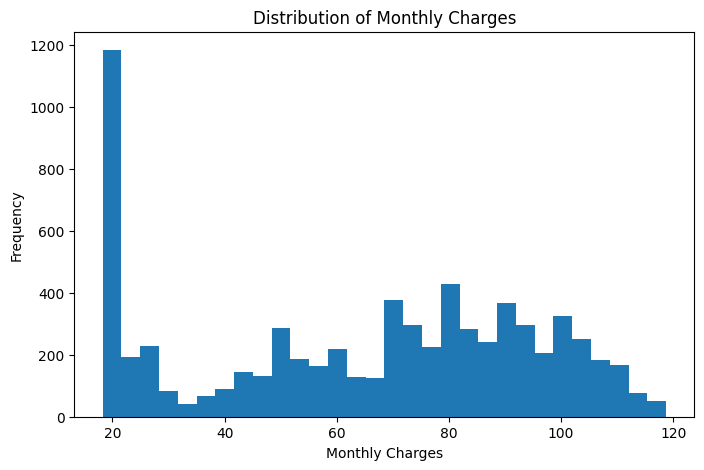

'Created histogram for Monthly Charges.'

In [58]:
visualize_column.invoke({
    "column_name": "Monthly Charges"
})

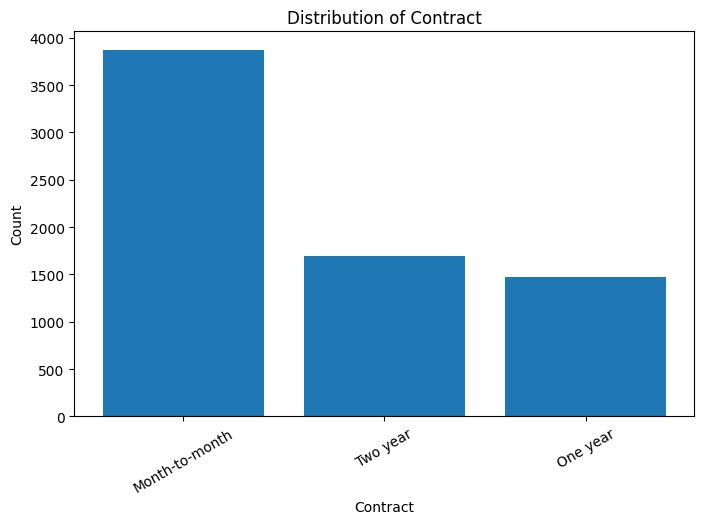

'Created bar chart for Contract.'

In [59]:
visualize_column.invoke({
    "column_name": "Contract"
})

In [60]:
!pip install -U langchain-groq

In [61]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    groq_api_key=api_key,
    temperature=0
)

tools = [
    dataset_overview,
    column_statistics,
    churn_analysis,
    visualize_column
]

llm_with_tools = llm.bind_tools(tools)

In [62]:
# bind tools to the LLM
tools = [
    dataset_overview,
    column_statistics,
    churn_analysis,
    visualize_column
]

llm_with_tools = llm.bind_tools(tools)

In [63]:
response = llm_with_tools.invoke(
    "How many customers are in the dataset?"
)

print(response)

content='' additional_kwargs={'reasoning_content': 'We need to get dataset overview. Use functions.dataset_overview.', 'tool_calls': [{'id': 'fc_044b03bc-0a2b-4dd2-9f3d-10d7d83aa618', 'function': {'arguments': '{}', 'name': 'dataset_overview'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 189, 'total_tokens': 223, 'completion_time': 0.034930703, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.009157093, 'prompt_tokens_details': None, 'queue_time': 0.394371828, 'total_time': 0.044087796}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d23c14756c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a06d03-1e4d-78d0-99b9-1d745960eab2-0' tool_calls=[{'name': 'dataset_overview', 'args': {}, 'id': 'fc_044b03bc-0a2b-4dd2-9f3d-10d7d83aa618', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 189, 'output_tokens'

In [64]:
response = llm_with_tools.invoke(
    "How many customers are in the dataset?"
)

print(response)

content='' additional_kwargs={'reasoning_content': 'We need to get dataset overview. Use functions.dataset_overview.', 'tool_calls': [{'id': 'fc_0e775dbd-2a07-4068-bfdd-edba90576bbb', 'function': {'arguments': '{}', 'name': 'dataset_overview'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 189, 'total_tokens': 223, 'completion_time': 0.036004015, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.009271006, 'prompt_tokens_details': None, 'queue_time': 0.391401956, 'total_time': 0.045275021}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8b41efc9a3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a06d03-9206-7273-850b-f8477dbc333c-0' tool_calls=[{'name': 'dataset_overview', 'args': {}, 'id': 'fc_0e775dbd-2a07-4068-bfdd-edba90576bbb', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 189, 'output_tokens'

In [65]:
response = llm_with_tools.invoke(
    "What percentage of customers have churned?"
)

print(response)

content='' additional_kwargs={'reasoning_content': 'We need to compute churn percentage. Likely dataset has churn column. We need to call churn_analysis.', 'tool_calls': [{'id': 'fc_263432e2-80e7-4d45-b143-2f211620f939', 'function': {'arguments': '{"":""}', 'name': 'churn_analysis'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 189, 'total_tokens': 234, 'completion_time': 0.050179417, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.010699643, 'prompt_tokens_details': None, 'queue_time': 0.559123845, 'total_time': 0.06087906}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_639a5351c8', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a06d04-7489-76d0-a73e-a95bff326a06-0' tool_calls=[{'name': 'churn_analysis', 'args': {'': ''}, 'id': 'fc_263432e2-80e7-4d45-b143-2f211620f939', 'type': 'tool_call'}] invalid_tool_calls=[] usage_met

In [66]:
response = llm_with_tools.invoke(
    "Show me the distribution of Contract."
)

print(response)

content='' additional_kwargs={'reasoning_content': 'We need to call visualize_column with column_name "Contract".', 'tool_calls': [{'id': 'fc_8aed129f-7453-4195-a0ef-d4fb4b6dd947', 'function': {'arguments': '{"column_name":"Contract"}', 'name': 'visualize_column'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 188, 'total_tokens': 226, 'completion_time': 0.051186959, 'completion_tokens_details': {'reasoning_tokens': 13}, 'prompt_time': 0.010609578, 'prompt_tokens_details': None, 'queue_time': 0.343055965, 'total_time': 0.061796537}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_63473661d7', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a06d04-e05b-7bf0-bddc-57073f823262-0' tool_calls=[{'name': 'visualize_column', 'args': {'column_name': 'Contract'}, 'id': 'fc_8aed129f-7453-4195-a0ef-d4fb4b6dd947', 'type': 'tool_call'}] invalid_tool_calls=[] usage_

In [67]:
from typing import TypedDict


class AnalystState(TypedDict):
    messages: list

In [69]:
!pip install langgraph

  Using cached langgraph-1.2.11-py3-none-any.whl.metadata (4.9 kB)
  Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached ormsgpack-1.12.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.2 kB)
  Using cached websockets-16.1.1-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (6.8 kB)
Using cached langgraph-1.2.11-py3-none-any.whl (248 kB)
Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl (56 kB)
Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl (41 kB)
Using cached langgraph_sdk-0.4.4-py3-none-any.whl (162 kB)
Using cached websockets-16.1.1-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl (187 kB)
Using cached ormsgpack-1.12.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (212 kB)
  Attempting uni

In [70]:
from langgraph.graph import StateGraph, START, END


def call_llm(state: AnalystState):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [73]:
graph_builder = StateGraph(AnalystState)

graph_builder.add_node(
    "llm",
    call_llm
)

graph_builder.add_edge(
    START,
    "llm"
)

graph_builder.add_edge(
    "llm",
    END
)

graph = graph_builder.compile()


In [74]:
from langchain_core.messages import HumanMessage


result = graph.invoke({
    "messages": [
        HumanMessage(
            content="What is the average Monthly Charges?"
        )
    ]
})

result

{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to compute average Monthly Charges. We have dataset? We need to call dataset_overview? But we need column statistics. Use column_statistics with column_name "MonthlyCharges". Let\'s call function.', 'tool_calls': [{'id': 'fc_af09f0b1-d0eb-4dc3-81b9-5fc62c3664ae', 'function': {'arguments': '{"column_name":"MonthlyCharges"}', 'name': 'column_statistics'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 188, 'total_tokens': 254, 'completion_time': 0.06689887, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.010536972, 'prompt_tokens_details': None, 'queue_time': 0.303940592, 'total_time': 0.077435842}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06d06-a5d9-70a3-9592-5d288942a472-0', 